In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import ParameterGrid


In [61]:
# Data
data = "data/output/02_data_understanding/clean_data_train.csv"

# Load data
df = pd.read_csv(data)
df.describe()

# theme of plots 'viridis'

,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,numRegions,userReviewsTotal,totalRecognitions,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
count,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,...,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000
mean,7.115757,1990.937029,55.383346,246.218891,51.289249,1.672094,2.711038,2.916661,2.922972,0.596930,...,0.000072,0.001291,0.000789,0.000072,0.014990,0.003658,0.000359,0.002725,0.000072,0.000072
std,1.397509,26.489942,33.982376,884.273132,68.327586,6.534696,2.683848,4.325575,10.489713,2.365819,...,0.008469,0.035908,0.028078,0.008469,0.121515,0.060371,0.018934,0.052136,0.008469,0.008469
min,1.000000,1878.000000,0.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1976.000000,30.000000,15.000000,16.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,1996.000000,50.000000,34.000000,34.000000,0.000000,2.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,2012.000000,90.000000,126.000000,62.000000,1.000000,3.000000,3.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,2024.000000,176.000000,14906.000000,1885.000000,122.000000,8.000000,45.000000,296.000000,49.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [62]:
# Supponiamo che df_Z sia il tuo DataFrame con le feature numeriche
numCol = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

# Normalizza i dati
scaler = MinMaxScaler()
df_Z = scaler.fit_transform(df[numCol])

In [63]:
# # Supponiamo che df sia il tuo DataFrame con le feature numeriche
# numCol = [
#     "criticReviewsTotal",
#     "numRegions",
#     "numVotes",
#     "runtimeMinutes",
#     "totalCredits",
#     "totalMedia",
#     "totalRecognitions",
#     "userReviewsTotal"
# ]

# # Normalizzazione dei dati
# scaler = MinMaxScaler()
# df_Z = scaler.fit_transform(df[numCol])

# # Calcolare le distanze tra tutti i punti
# distances_matrix = pairwise_distances(df_Z, metric='euclidean')

# # Parametri da provare per DBSCAN
# eps_range = np.arange(0.03, 0.05, 0.002)  # Proviamo valori di eps tra 0.02 e 0.06
# min_samples_range = list(range(4, 200, 2))  # Genera una lista di valori per min_samples da 10 a 200 con un passo di 1

# # Grid di combinazioni dei parametri
# param_grid = ParameterGrid({'eps': eps_range, 'min_samples': min_samples_range})

# # Lista per memorizzare tutti i risultati
# all_results = []

# # Iterare su tutte le combinazioni di eps e min_samples
# total_combinations = len(param_grid)
# current_iteration = 0

# for params in param_grid:
#     eps = params['eps']
#     min_samples = params['min_samples']
    
#     # Esegui DBSCAN con i parametri correnti usando le distanze pre-calcolate
#     db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
#     labels = db.fit_predict(distances_matrix)
    
#     # Ignora le configurazioni con un solo cluster (o rumore)
#     if len(set(labels)) > 1:
#         silhouette_avg = silhouette_score(df_Z, labels)
#         num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Escludi il cluster -1 (rumore)
#         num_outliers = list(labels).count(-1)  # Conta il numero di outlier
        
#         # Aggiungi i risultati alla lista solo se ci sono almeno 2 cluster
#         if num_clusters >= 1:
#             all_results.append({
#                 'eps': eps,
#                 'min_samples': min_samples,
#                 'silhouette_score': silhouette_avg,
#                 'num_clusters': num_clusters,
#                 'num_outliers': num_outliers
#             })
    
#     # Stampa progresso
#     current_iteration += 1
#     print(f"Progress: {current_iteration}/{total_combinations} iterations completed.", end='\r')

# # Ordina tutti i risultati per silhouette_score in ordine decrescente
# all_results = sorted(all_results, key=lambda x: x['silhouette_score'], reverse=True)

# # Converti i risultati in un DataFrame
# all_results_df = pd.DataFrame(all_results)

# # Salva i risultati in un file CSV
# all_results_df.to_csv('all_dbscan_results.csv', index=False)

# # Stampa i primi 20 risultati
# print("\nTop 20 DBSCAN configurations based on Silhouette Score:")
# for i, result in enumerate(all_results[:20]):
#     print(f"{i+1}. eps={result['eps']:.3f}, min_samples={result['min_samples']}, "
#           f"Silhouette Score={result['silhouette_score']:.4f}, num_clusters={result['num_clusters']}, "
#           f"num_outliers={result['num_outliers']}")

# All features

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler

def load_labels_from_txt(txt_path):
    """
    Carica le etichette da un file di testo.

    Args:
        txt_path (str): Il percorso del file di testo.

    Returns:
        dict: Un dizionario con le etichette mappate.
    """
    labels = {}
    with open(txt_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(': ')
            labels[int(value)] = key
    return labels

def plot_dbscan_clusters(df, eps, min_samples, y_mapped, txt_path="./encoding_lists/titleType.txt", remove_column=None):
    """
    Esegue il clustering DBSCAN e traccia i centri dei cluster.

    Parameters:
    df (DataFrame): Il DataFrame contenente i dati.
    eps (float): Il raggio massimo di vicinanza per includere i punti in un cluster.
    min_samples (int): Il numero minimo di punti per formare un cluster.
    y_mapped (Series): Serie contenente le etichette mappate.
    txt_path (str): Il percorso del file di testo contenente le etichette.
    remove_column (str): Nome della colonna da rimuovere dal grafico.
    """
    # Carica le etichette dal file di testo
    labels_dict = load_labels_from_txt(txt_path)

    # Normalizza i dati
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df)

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df_scaled)

    # Aggiungi le etichette dei cluster al DataFrame
    df['dbscan_labels'] = labels

    # Calcola i centri dei cluster
    unique_labels = set(labels)
    centers = []
    for label in unique_labels:
        if label != -1:  # Escludi il rumore
            centers.append(df_scaled[labels == label].mean(axis=0))
    centers = scaler.inverse_transform(centers) if centers else []

    # Imposta la dimensione dinamica in base al numero di colonne
    fig_width = len(df.columns) * 1  # Dimensione dinamica
    fig_height = 4  # Altezza fissa per uniformare le dimensioni tra i grafici

    # Primo grafico: Centri dei cluster
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    clust_name = [chr(65 + i) for i in range(len(centers))]  # Genera nomi di cluster A, B, C, ...

    for i in range(len(centers)):
        ax.plot(centers[i], marker='o', label=clust_name[i])

    ax.set_xticks(range(0, len(df.columns) - 1))
    ax.set_xticklabels(df.columns[:-1], fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.set_title(f'DBSCAN Clustering with eps={eps}, min_samples={min_samples} (All Columns)')
    ax.grid(axis='y')

    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')  # Allinea a destra

    ax.legend(fontsize=13, loc='upper left', bbox_to_anchor=(1, 1))  # Aggiungi la legenda separata
    plt.show()

    # Secondo grafico: Centri dei cluster senza la colonna specificata
    if remove_column and remove_column in df.columns:
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        columns_to_plot = df.drop(columns=[remove_column, 'dbscan_labels']).columns

        for i in range(len(centers)):
            centers_to_plot = np.delete(centers[i], df.columns.get_loc(remove_column))
            ax.plot(centers_to_plot, marker='o', label=clust_name[i])

        ax.set_xticks(range(0, len(columns_to_plot)))
        ax.set_xticklabels(columns_to_plot, fontsize=13)
        ax.tick_params(axis='y', labelsize=13)
        ax.set_title(f'DBSCAN Clustering with eps={eps}, min_samples={min_samples} (Without {remove_column})')
        ax.grid(axis='y')

        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')  # Allinea a destra

        ax.legend(fontsize=13, loc='upper left', bbox_to_anchor=(1, 1))  # Aggiungi la legenda separata
        plt.show()

    # Terzo grafico: Distribuzione delle etichette di cluster
    bar_pl = y_mapped.groupby(df['dbscan_labels']).value_counts(normalize=True).unstack(1)
    bar_pl = bar_pl.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    bar_pl.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5, ax=ax)

    ax.set_xticks(range(0, len(unique_labels)))
    ax.set_xticklabels([f'Cluster {i}' if i != -1 else 'Noise' for i in unique_labels], fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.legend(bbox_to_anchor=(1, 1))
    ax.set_ylabel('Proportion of elements by titleType')
    ax.set_title('Distribution of Cluster Labels')

    plt.show()

    # Quarto grafico: Numero di elementi in ciascun cluster raggruppati per y_mapped
    cluster_counts = df.groupby(['dbscan_labels', y_mapped]).size().unstack().fillna(0)
    cluster_counts = cluster_counts.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    cluster_counts.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5, ax=ax)

    ax.set_xticks(range(0, len(unique_labels)))
    ax.set_xticklabels([f'Cluster {i}' if i != -1 else 'Noise' for i in unique_labels], fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Elements')
    ax.set_title(f'Number of Elements in Each Cluster Grouped by {y_mapped.name}')
    ax.legend(title=y_mapped.name, bbox_to_anchor=(1, 1))

    plt.show()


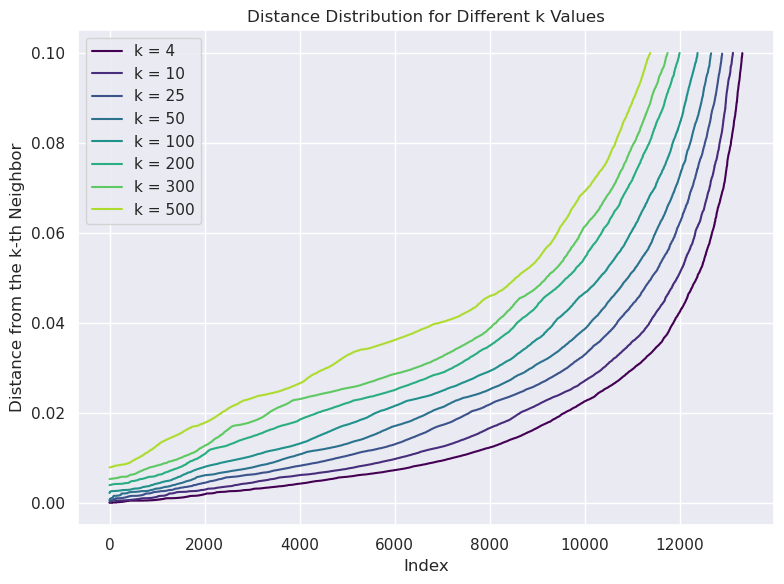

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# Dati di esempio (df_Z è il tuo DataFrame)
# df_Z = ... (Assicurati di avere il tuo dataset df_Z)

# I due valori di k da comparare
k_values = [4, 10, 25, 50, 100, 200, 300, 500]

# Calcola la matrice delle distanze Euclidee
dist = pdist(df_Z, 'euclidean')
dist = squareform(dist)

# Imposta il grafico
plt.figure(figsize=(8, 6))  # Grafico più grande

# Imposta il tema di Seaborn
sns.set_style('whitegrid')
sns.set_theme(palette='viridis')

# Threshold per tagliare il grafico
threshold = 0.1  # Imposta il valore di threshold (modifica secondo necessità)

# Calcola e traccia i dati per ciascun valore di k
for idx, k in enumerate(k_values):
    kth_distances = []
    
    for d in dist:  # d è un vettore contenente le distanze tra il punto i-esimo e tutti gli altri
        index_kth_distance = np.argsort(d)[k]  # Trova l'indice del k-esimo vicino più prossimo
        kth_distances.append(d[index_kth_distance])  # Memorizza la distanza
    
    # Taglia i valori sopra il threshold
    kth_distances = [d for d in kth_distances if d <= threshold]

    # Scegli un colore diverso per ciascun grafico
    color = plt.cm.viridis(idx / len(k_values))  # Differenti colori dal colormap viridis
    
    # Plot dei risultati
    plt.plot(range(0, len(kth_distances)), sorted(kth_distances), label=f'k = {k}', color=color)

# Aggiungi etichette e titolo
plt.xlabel('Index')
plt.ylabel('Distance from the k-th Neighbor')
plt.title('Distance Distribution for Different k Values')
plt.grid(True)

# Aggiungi legenda
plt.legend()

# Aggiungi il tema viridis
plt.set_cmap('viridis')

# Mostra il grafico
plt.tight_layout()
plt.show()


/tmp/ipykernel_5917/2808076674.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_labels'] = labels


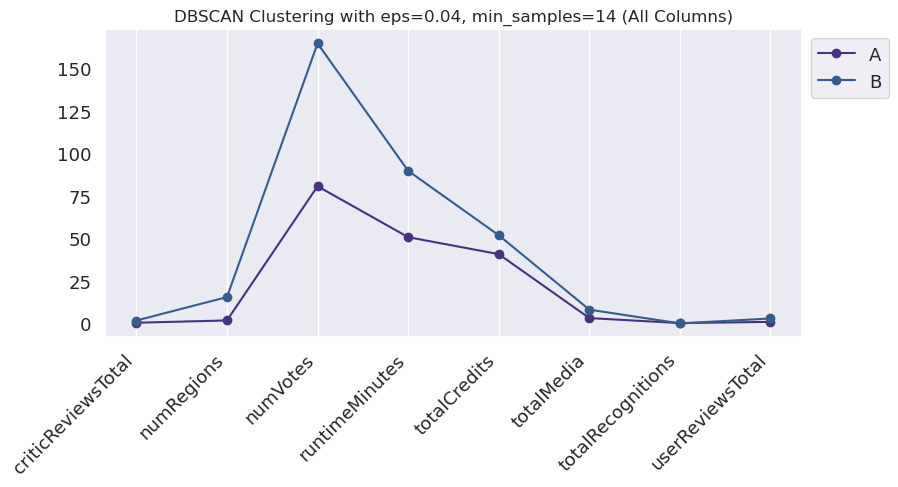

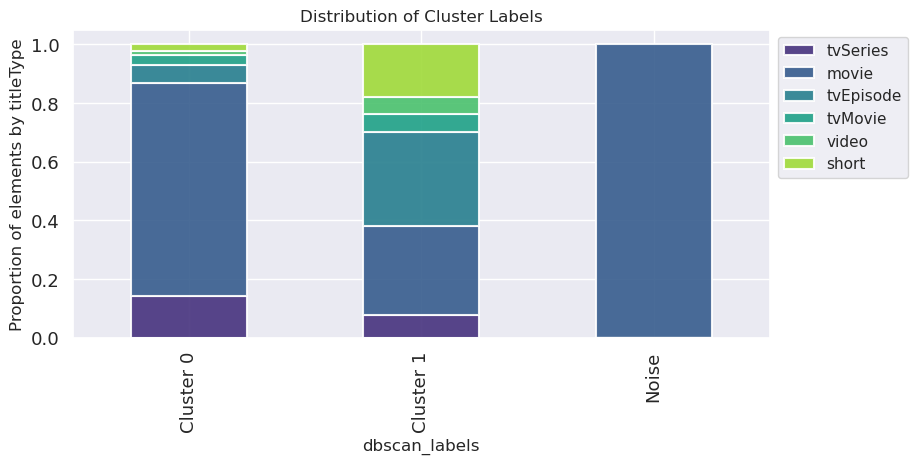

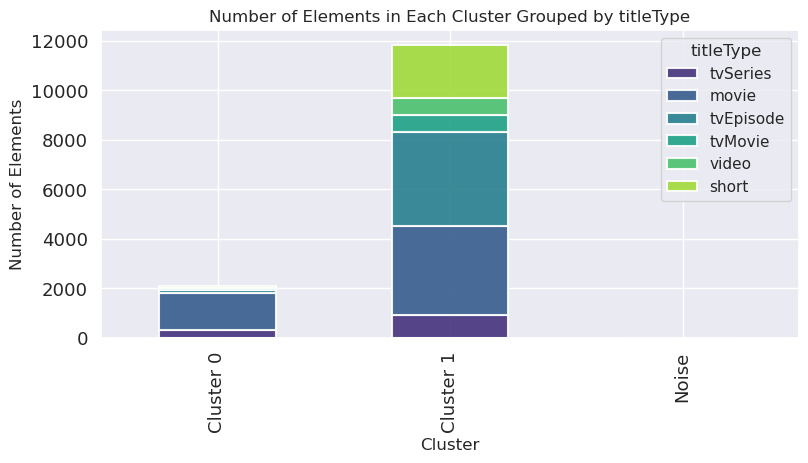

In [90]:
plot_dbscan_clusters(df[numCol], 0.04, 14, df['titleType'])

/tmp/ipykernel_5917/2808076674.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_labels'] = labels


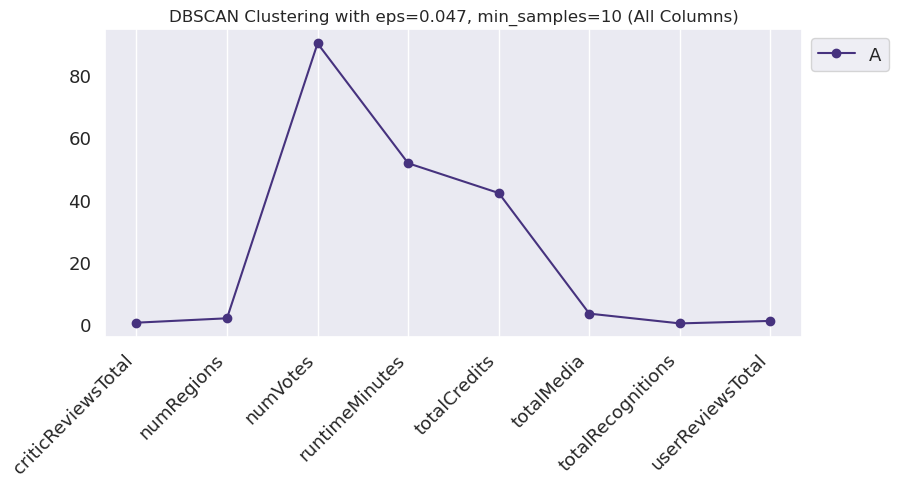

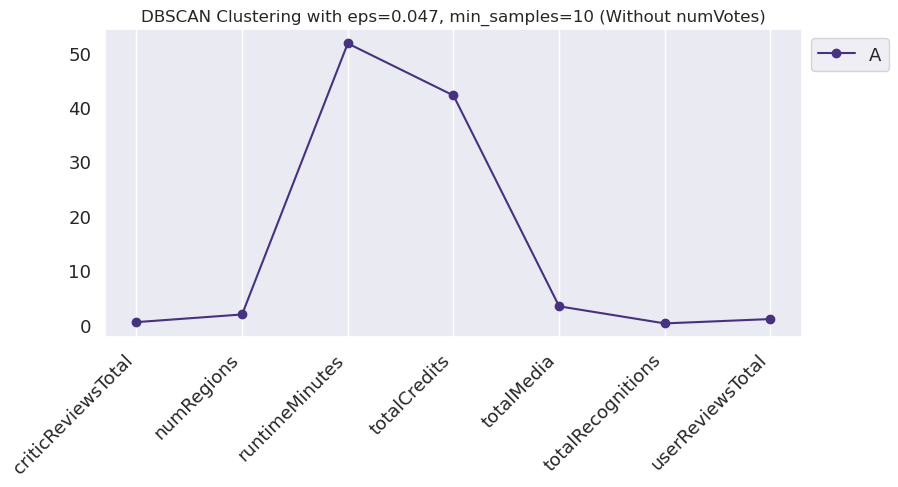

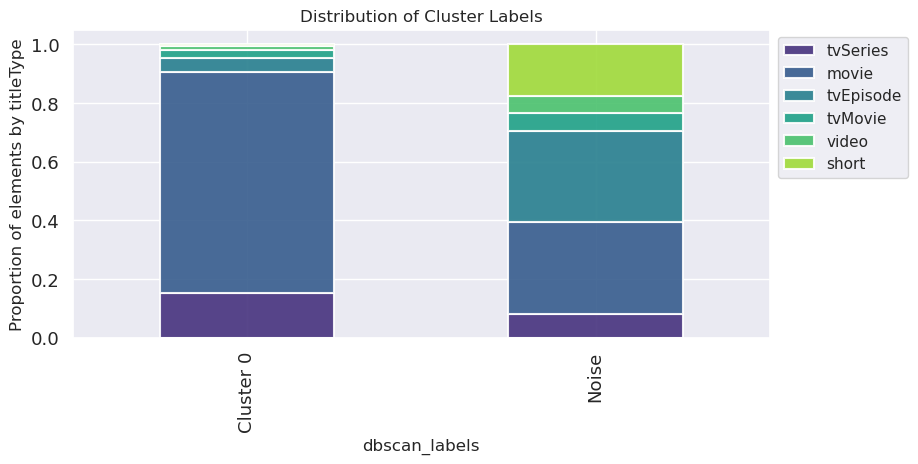

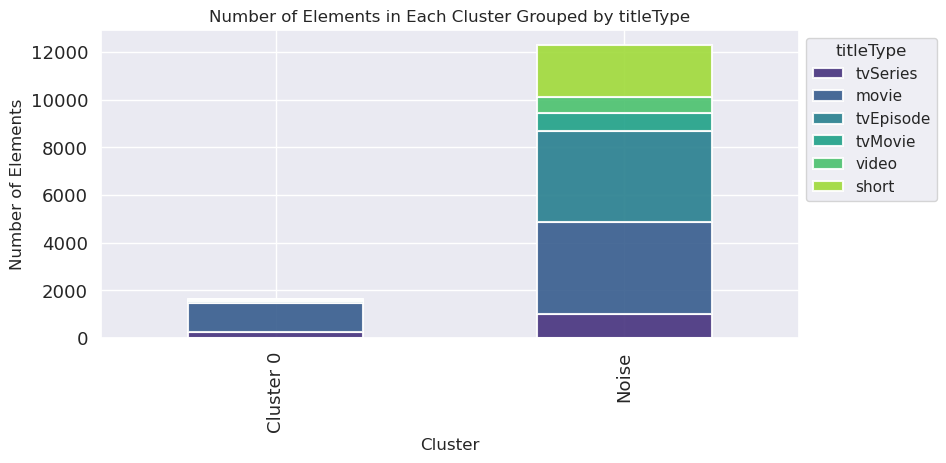

In [89]:
plot_dbscan_clusters(df[numCol], 0.047, 10, df['titleType'], remove_column='numVotes')
# print silhouette score

# Selected features

In [56]:
# Supponiamo che df_Z sia il tuo DataFrame con le feature numeriche
numCol = [
    "criticReviewsTotal",
#    "numRegions",
#    "numVotes",
    "runtimeMinutes",
    "totalCredits",
#    "totalMedia",
#    "totalRecognitions",
    "userReviewsTotal"
]

In [57]:

# Normalizza i dati
scaler = MinMaxScaler()
data = scaler.fit_transform(df[numCol])

# Definisci i range di valori per min_samples e eps
min_samples_range = range(2, 10)
eps_range = np.arange(0.02, 0.06, 0.001)

# Definisci la lista dei target_clusters
target_clusters_list = [4, 5, 6, 7, 8, 9, 10]

# Trova i valori ottimali di min_samples e eps per ciascun valore di target_clusters
optimal_params = find_best_dbscan_params(data, min_samples_range, eps_range, target_clusters_list)
for target_clusters in target_clusters_list:
    print(f"Optimal params for {target_clusters} clusters: min_samples={optimal_params[target_clusters]['min_samples']}, eps={optimal_params[target_clusters]['eps']}")

Testing min_samples=9, eps=0.99 (792/792)0001 (789/792)))
Optimal params for 4 clusters: min_samples=2, eps=0.14
Optimal params for 5 clusters: min_samples=2, eps=0.13
Optimal params for 6 clusters: min_samples=None, eps=None
Optimal params for 7 clusters: min_samples=2, eps=0.12
Optimal params for 8 clusters: min_samples=None, eps=None
Optimal params for 9 clusters: min_samples=2, eps=0.09999999999999999
Optimal params for 10 clusters: min_samples=None, eps=None


- Testing min_samples=9, eps=0.99 (792/792)0001 (789/792)))
- Optimal params for 4 clusters: min_samples=2, eps=0.14
- Optimal params for 5 clusters: min_samples=2, eps=0.13
- Optimal params for 6 clusters: min_samples=None, eps=None
- Optimal params for 7 clusters: min_samples=2, eps=0.12
- Optimal params for 8 clusters: min_samples=None, eps=None
- Optimal params for 9 clusters: min_samples=2, eps=0.09999999999999999
- Optimal params for 10 clusters: min_samples=None, eps=None

/tmp/ipykernel_21375/3753529935.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_labels'] = labels


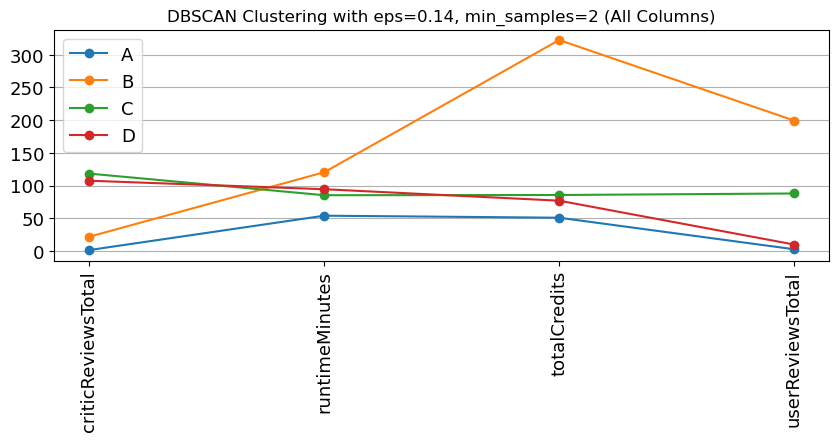

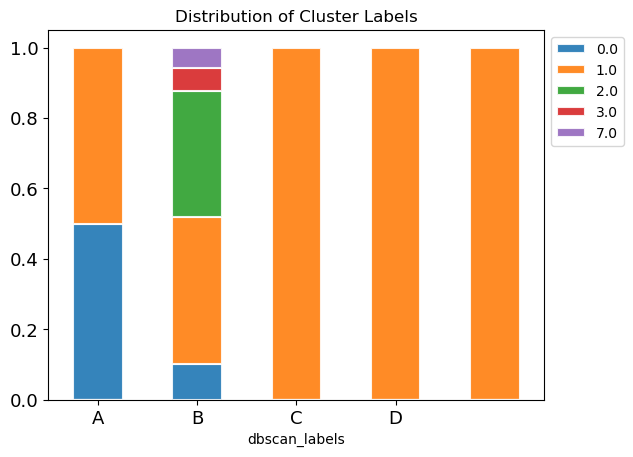

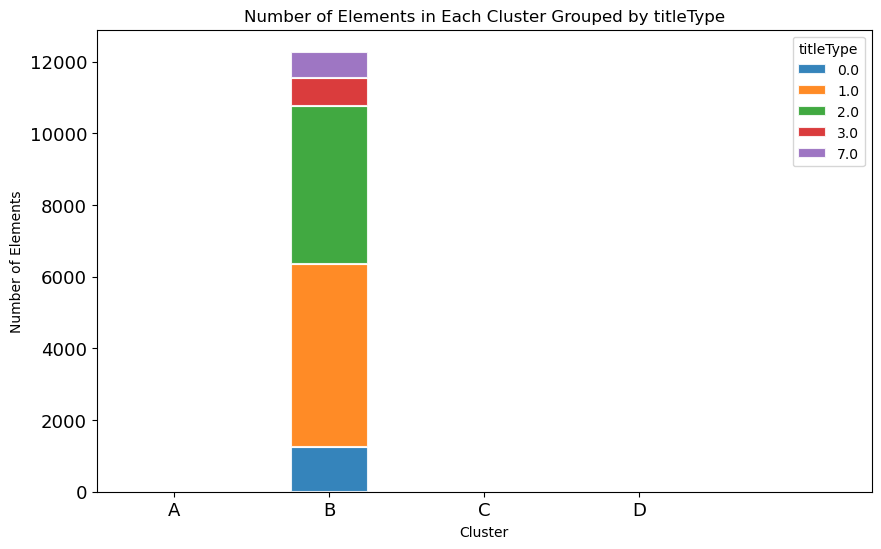

In [58]:

plot_dbscan_clusters(df[numCol], eps=0.14, min_samples=2, y_mapped=df['titleType'], remove_column=None)

/tmp/ipykernel_21375/3753529935.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_labels'] = labels


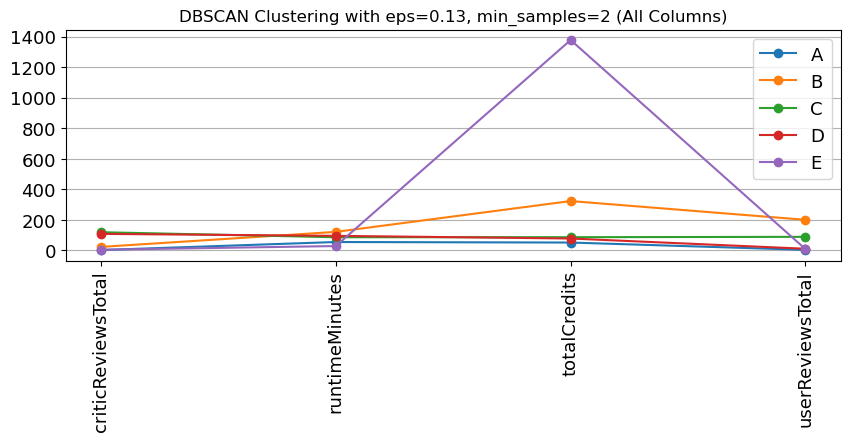

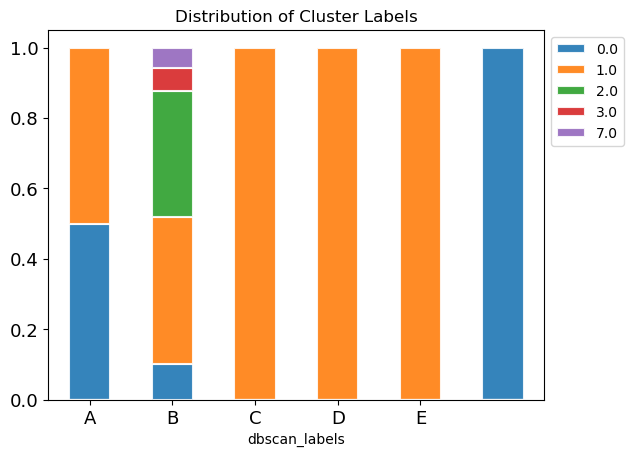

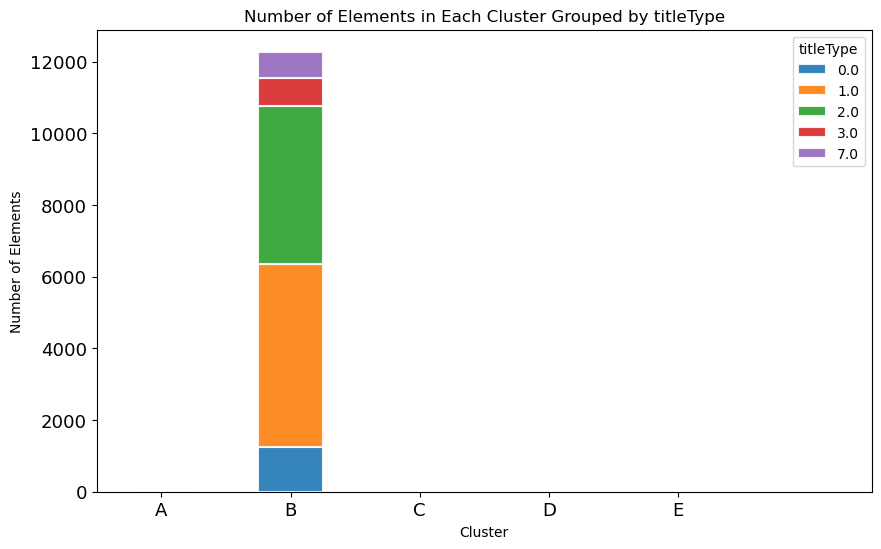

In [59]:
plot_dbscan_clusters(df[numCol], eps=0.13, min_samples=2, y_mapped=df['titleType'], remove_column=None)

/tmp/ipykernel_21375/3753529935.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_labels'] = labels


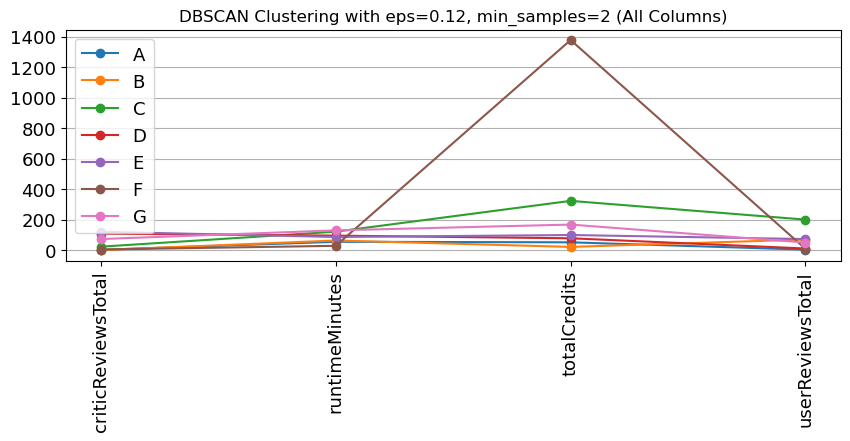

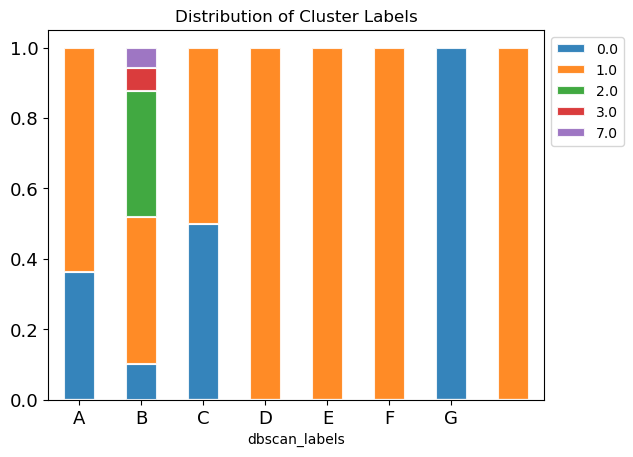

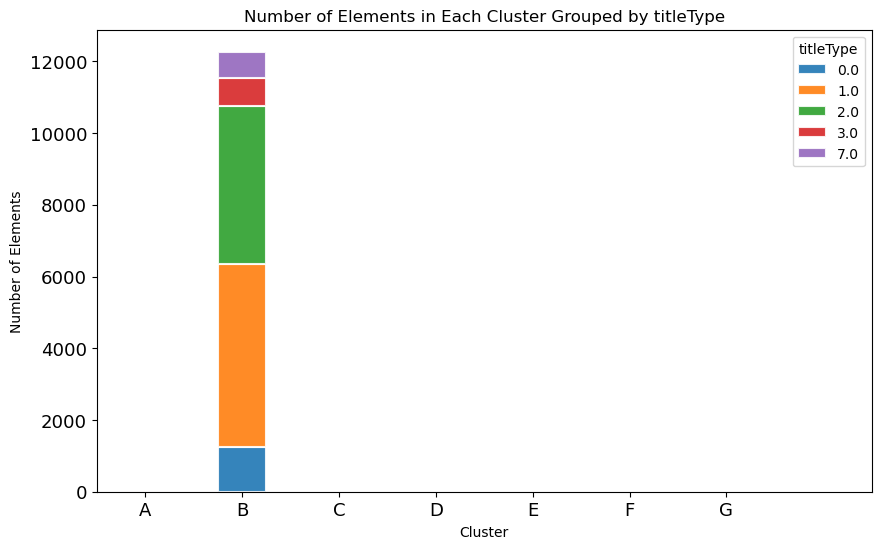

In [60]:
plot_dbscan_clusters(df[numCol], eps=0.12, min_samples=2, y_mapped=df['titleType'], remove_column=None)

/tmp/ipykernel_21375/3753529935.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_labels'] = labels


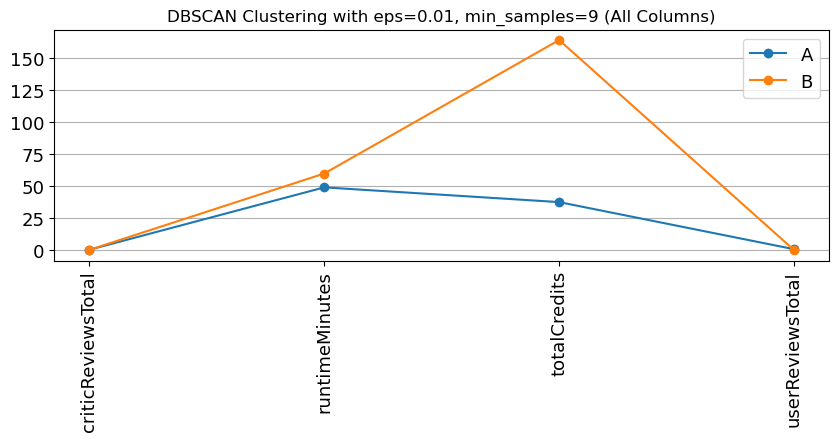

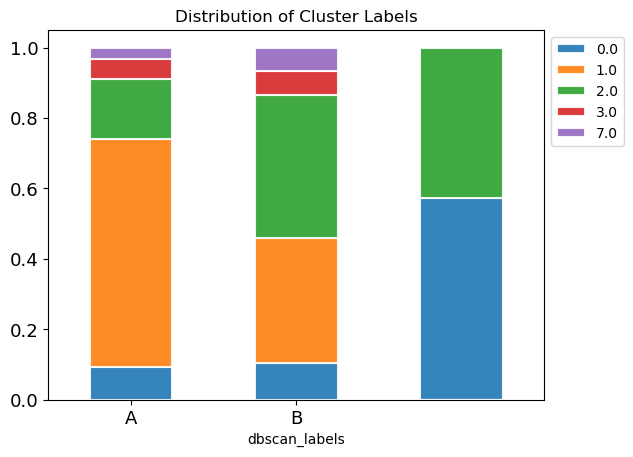

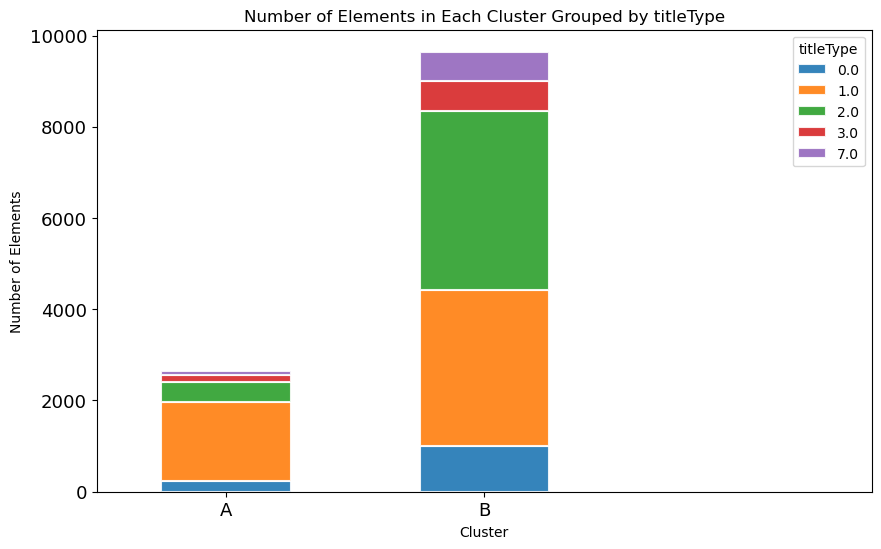

In [68]:
plot_dbscan_clusters(df[numCol], eps=0.01, min_samples=9, y_mapped=df['titleType'], remove_column=None)

In [7]:
# Supponiamo che df_Z sia il tuo DataFrame con le feature numeriche
numCol = [
    "criticReviewsTotal",
#    "numRegions",
    "numVotes",
    "runtimeMinutes",
#    "totalCredits",
    "totalMedia",
#    "totalRecognitions",
#    "userReviewsTotal"
]

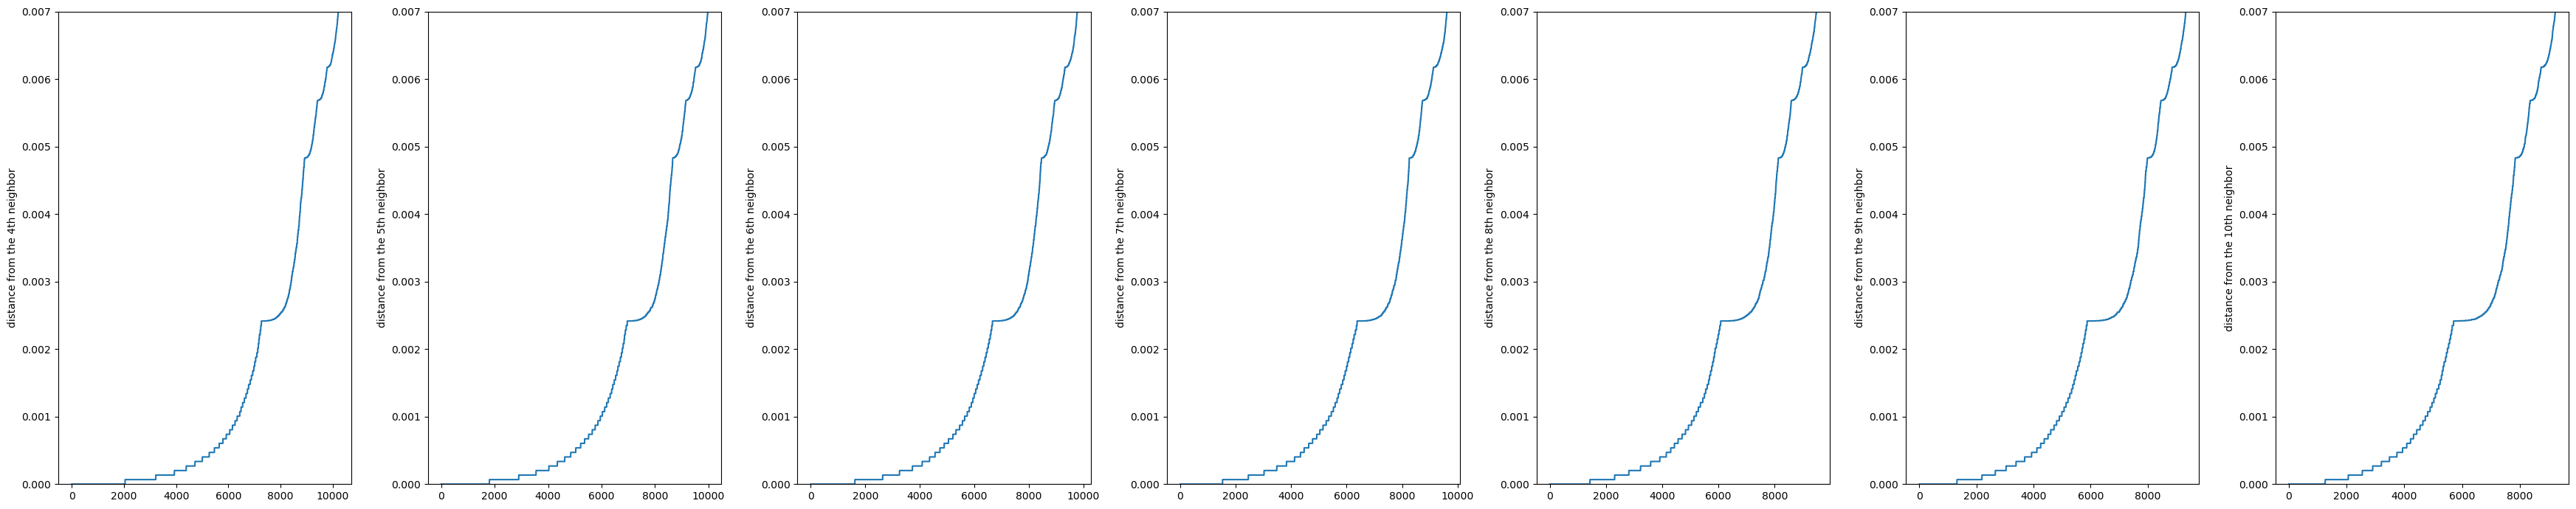

In [9]:
# Normalizza i dati
scaler = MinMaxScaler()
df_Z = scaler.fit_transform(df[numCol])

# Calcola la matrice delle distanze
dist = pdist(df_Z, 'euclidean')
dist = squareform(dist)

# Definisci i valori di k e la soglia per l'asse y
ks = [4, 5, 6, 7, 8, 9, 10]
y_threshold = 0.007  # Soglia per l'asse y

plt.figure(figsize=(len(ks)*5, 7))  # Dimensioni del grafico complessivo
fig_dims = (1, len(ks))

for i in range(len(ks)):
    k = ks[i]
    kth_distances = []

    for d in dist:  # d è un vettore contenente le distanze tra il record i-esimo e tutti gli altri
        index_kth_distance = np.argsort(d)[k]  # Prendi l'indice del k-esimo vicino più prossimo
        kth_distances.append(d[index_kth_distance])  # Memorizza la distanza in una lista

    # Filtra i valori sotto la soglia
    filtered_distances = [dist for dist in kth_distances if dist <= y_threshold]

    plt.subplot2grid(fig_dims, (0, i))
    plt.plot(range(0, len(filtered_distances)), sorted(filtered_distances))
    plt.ylabel(f'distance from the {k}th neighbor')
    plt.ylim(0, y_threshold)  # Imposta il limite dell'asse y

plt.tight_layout()
plt.show()

/tmp/ipykernel_22729/3753529935.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dbscan_labels'] = labels


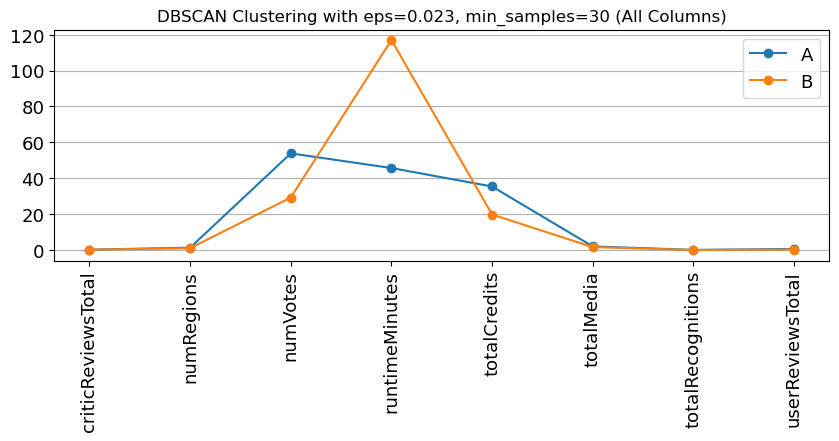

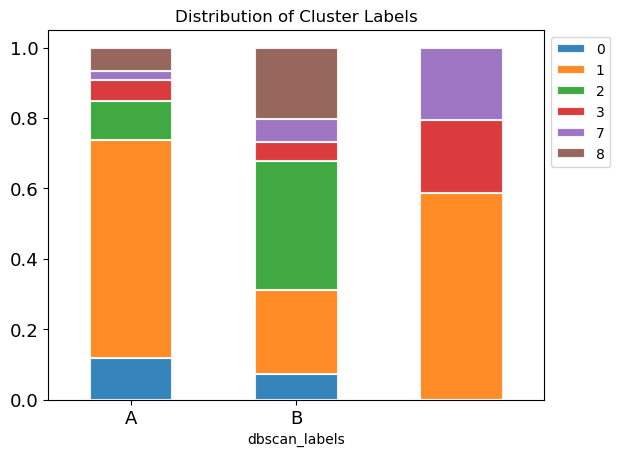

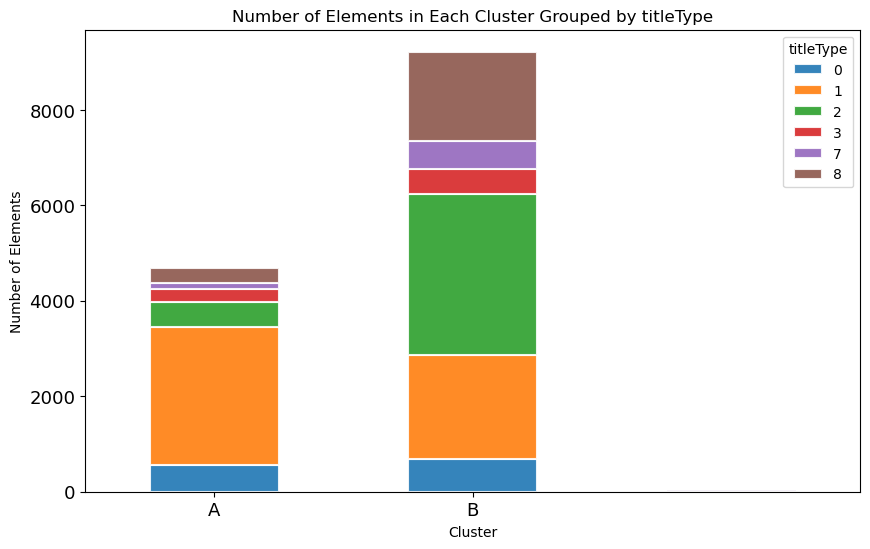

In [31]:
plot_dbscan_clusters(df[numCol], eps=0.023, min_samples=30, y_mapped=df['titleType'], remove_column=None)